### Segmentasi Pelanggan Menggunakan Gaussian Mixture Model (GMM)

#### Ujian Akhir Semester Machine Learning

| Keterangan | Isi |
|------------|-----|
| Nama | Shela Rahma Fitri |
| NIM | 24260012 |
| Prodi | teknik informatika |

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

#### 1. Memuat Dataset
Dataset yang digunakan adalah Mall Customer Dataset yang berisi informasi pelanggan seperti umur, pendapatan tahunan, dan skor pengeluaran.

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2. Memahami Dataset
Tahap ini dilakukan untuk mengetahui struktur data, tipe data, dan jumlah data yang tersedia.

In [4]:
df.info()

print("\nStatistik Deskriptif")
display(df.describe())

print("\nJumlah Missing Value")
display(df.isnull().sum().to_frame(name="Jumlah Missing"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Statistik Deskriptif


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Jumlah Missing Value


,Jumlah Missing
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### 3. Visualisasi EDA (Exploratory Data Analysis)

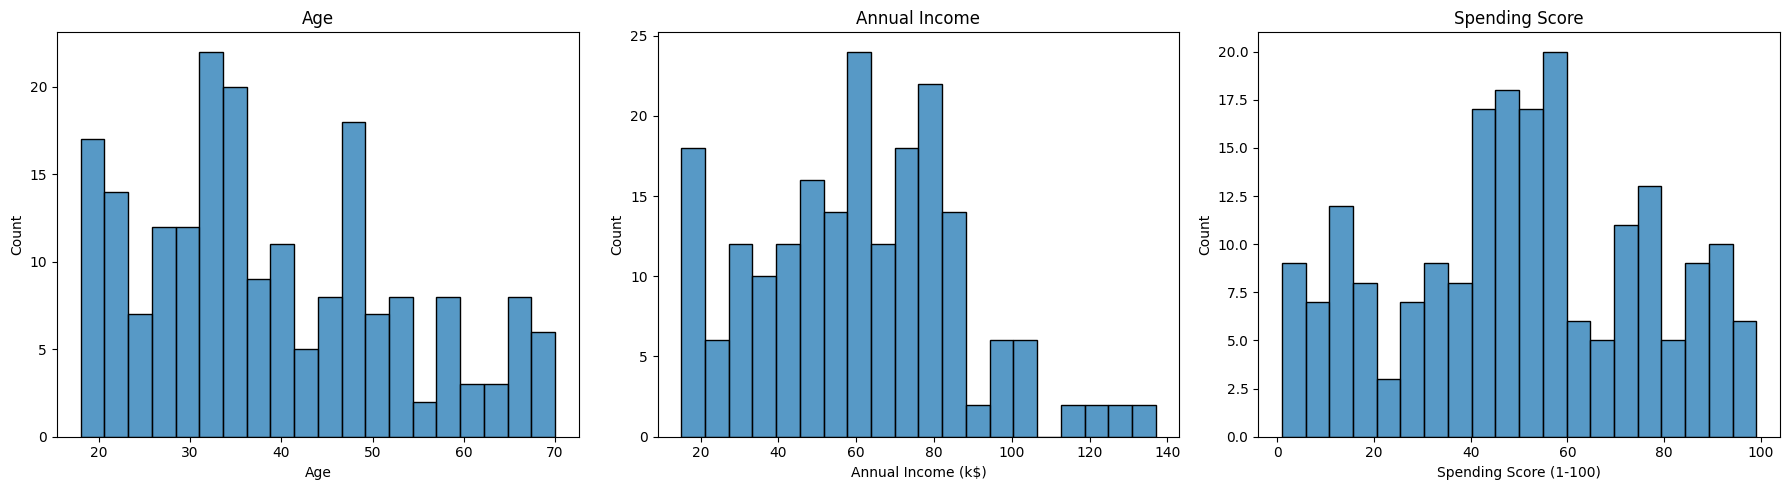

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["Age"], bins=20, ax=axes[0])
axes[0].set_title("Age")

sns.histplot(df["Annual Income (k$)"], bins=20, ax=axes[1])
axes[1].set_title("Annual Income")

sns.histplot(df["Spending Score (1-100)"], bins=20, ax=axes[2])
axes[2].set_title("Spending Score")

plt.tight_layout()
plt.show()

### 4. Pemilihan Fitur
Fitur yang digunakan dalam proses clustering adalah:
- Age
- Annual Income (k$)
- Spending Score (1-100)

In [6]:
X = df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]

### 5. Standardisasi Data
Standardisasi dilakukan agar seluruh fitur memiliki skala yang sebanding.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['Age', 'Annual Income', 'Spending Score']
)

X_scaled_df.head()

,Age,Annual Income,Spending Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


### 6. Menentukan Jumlah Cluster Terbaik

Sebelum membangun model Gaussian Mixture Model (GMM), perlu ditentukan jumlah cluster yang optimal. Pada tahap ini digunakan nilai BIC (Bayesian Information Criterion) dan AIC (Akaike Information Criterion). Nilai yang lebih kecil menunjukkan model yang lebih baik.

In [8]:
bic_scores = []
aic_scores = []

n_components = range(1, 11)

for n in n_components:
    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    gmm.fit(X_scaled)

    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

# Menentukan jumlah cluster terbaik berdasarkan BIC
best_bic_idx = np.argmin(bic_scores)
best_aic_idx = np.argmin(aic_scores)

best_cluster = n_components[best_bic_idx]

print("=== Hasil Evaluasi BIC & AIC ===")
print(f"BIC minimum = {bic_scores[best_bic_idx]:.3f} pada k = {best_cluster}")
print(f"AIC minimum = {aic_scores[best_aic_idx]:.3f} pada k = {n_components[best_aic_idx]}")

print("\nJumlah cluster terbaik berdasarkan BIC:", best_cluster)

=== Hasil Evaluasi BIC & AIC ===
BIC minimum = 1596.999 pada k = 4
AIC minimum = 1399.992 pada k = 9

Jumlah cluster terbaik berdasarkan BIC: 4


### 7. Evaluasi Jumlah Cluster Menggunakan BIC & AIC

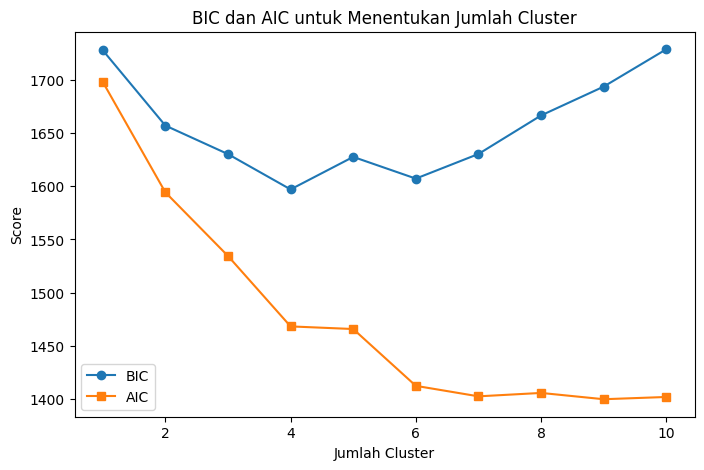

In [9]:
plt.figure(figsize=(8,5))

plt.plot(n_components, bic_scores, marker='o', label='BIC')
plt.plot(n_components, aic_scores, marker='s', label='AIC')

plt.xlabel('Jumlah Cluster')
plt.ylabel('Score')
plt.title('BIC dan AIC untuk Menentukan Jumlah Cluster')
plt.legend()

plt.show()

### 8. Membangun Model Gaussian Mixture Model (GMM)

Setelah diperoleh jumlah cluster optimal berdasarkan nilai BIC, model Gaussian Mixture Model dibangun menggunakan 4 cluster.

In [10]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm.fit(X_scaled)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


### 9. Menambahkan Label Cluster

Setiap pelanggan akan dikelompokkan ke dalam salah satu cluster yang dihasilkan oleh model GMM.

In [11]:
# Menambahkan label cluster ke dataset
df['Cluster'] = gmm.predict(X_scaled)

# Menampilkan 5 data pertama
display(df.head())

# Menampilkan jumlah anggota tiap cluster
print("Jumlah anggota pada setiap cluster:")
display(df['Cluster'].value_counts().to_frame(name="Jumlah Pelanggan"))

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


Jumlah anggota pada setiap cluster:


,Jumlah Pelanggan
Cluster,
0,76
2,51
1,39
3,34


### 10. Visualisasi Hasil Clustering

Visualisasi dilakukan menggunakan Annual Income dan Spending Score untuk melihat pola pengelompokan pelanggan.

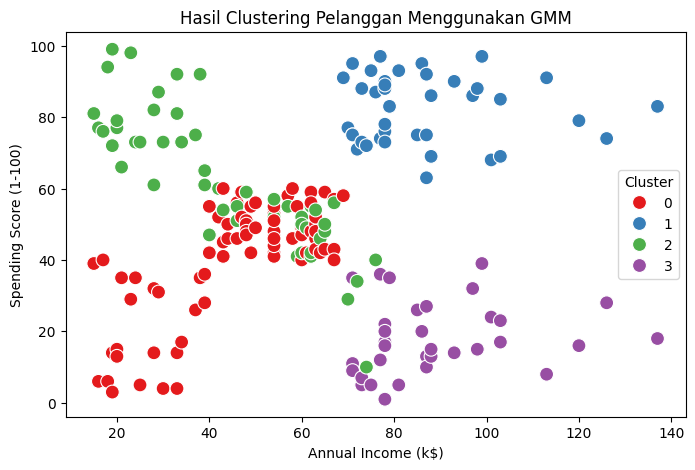

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Hasil Clustering Pelanggan Menggunakan GMM')
plt.show()

### 11. Evaluasi Model

Evaluasi dilakukan menggunakan Silhouette Score untuk mengukur kualitas hasil clustering.

In [13]:
score = silhouette_score(
    X_scaled,
    df['Cluster']
)

print("Silhouette Score :", score)

Silhouette Score : 0.3734466371028913


### 12. Analisis Karakteristik Cluster

Untuk memahami karakteristik masing-masing cluster, dilakukan perhitungan rata-rata umur, pendapatan tahunan, dan spending score pada setiap cluster.

Rata-rata karakteristik tiap cluster:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,50.18,45.84,40.70
1,32.69,86.54,82.13
2,24.33,43.90,61.75
3,42.35,88.65,17.50


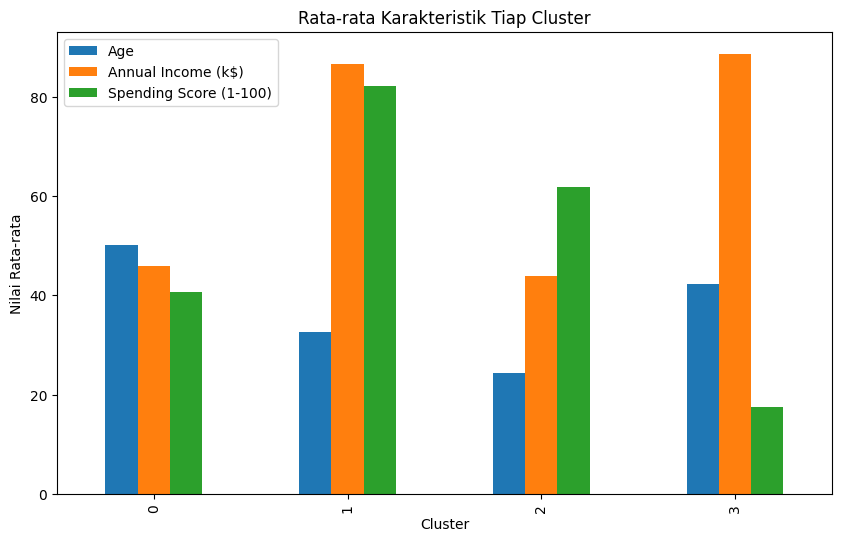

In [14]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean().round(2)

print("Rata-rata karakteristik tiap cluster:")
display(cluster_summary)

cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Rata-rata Karakteristik Tiap Cluster")
plt.ylabel("Nilai Rata-rata")
plt.show()



### 13. Interpretasi Hasil Clustering

Berdasarkan hasil clustering menggunakan Gaussian Mixture Model (GMM), diperoleh 4 kelompok pelanggan dengan karakteristik yang berbeda.



| Cluster | Rata-rata Umur | Rata-rata Pendapatan (k$) | Rata-rata Spending Score | Interpretasi |
|----------|----------|----------|----------|----------|
| 0 | 50.18 | 45.84 | 40.70 | Pelanggan berusia lebih tua dengan pengeluaran sedang. |
| 1 | 32.69 | 86.54 | 82.13 | Pelanggan dengan pendapatan dan pengeluaran tinggi. |
| 2 | 24.33 | 43.90 | 61.75 | Pelanggan muda dengan aktivitas belanja cukup tinggi. |
| 3 | 42.35 | 88.65 | 17.50 | Pelanggan berpendapatan tinggi tetapi pengeluaran rendah. |

### 14. Kesimpulan

Pada penelitian ini telah dilakukan segmentasi pelanggan menggunakan metode Gaussian Mixture Model (GMM) pada dataset Mall Customers.

Berdasarkan evaluasi menggunakan nilai BIC, diperoleh jumlah cluster optimal sebanyak 4 cluster. Hasil clustering menunjukkan bahwa pelanggan dapat dikelompokkan menjadi beberapa karakteristik yang berbeda berdasarkan umur, pendapatan tahunan, dan tingkat pengeluaran.

Nilai Silhouette Score yang diperoleh sebesar 0.3734 menunjukkan bahwa kualitas clustering berada pada kategori cukup baik. Hasil segmentasi menghasilkan kelompok pelanggan dengan karakteristik pendapatan tinggi dan pengeluaran tinggi, pendapatan tinggi namun pengeluaran rendah, pelanggan muda dengan pengeluaran aktif, serta pelanggan dengan karakteristik pengeluaran sedang.

Hasil clustering ini dapat dimanfaatkan untuk membantu perusahaan dalam memahami karakteristik pelanggan dan menyusun strategi pemasaran yang lebih tepat sasaran.